<a href="https://colab.research.google.com/github/atikhasan007/DeepLearning/blob/main/pytorch/07_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1) Design model (input, output size , forward pass)
# 2) Construct loss and optimizer
# 3) Training loop
# - forward pass: compute prediction and loss
# - backward pass : gradients
# - update weights


In [1]:
import torch
import torch.nn as nn
import numpy as np
from sklearn import datasets
import matplotlib.pyplot as plt


**step 0: prepare data**

In [2]:
X_numpy , y_numpy = datasets.make_regression(
    n_samples=100,
    n_features=1,
    noise=20,
    random_state=1
)

# make_regression() থেকে যে data পাই, সেটা NumPy array আকারে থাকে। কিন্তু PyTorch model train করতে হলে data Tensor হতে হবে।

In [3]:
x = torch.from_numpy(X_numpy.astype(np.float32))
y = torch.from_numpy(y_numpy.astype(np.float32))

In [19]:
print(x.shape)

torch.Size([100, 1])


In [22]:
y = y.view(y.shape[0], 1)

In [25]:
n_samples, n_features = x.shape

In [8]:
n_samples

100

In [9]:
n_features

1

**step 1: Model**

In [10]:
input_size = n_features
output_size = 1
model = nn.Linear(input_size, output_size)


**step 2: loss and optimizer**

In [11]:
learning_rate = 0.01
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(),
                            lr=learning_rate)

**step 3: training loop**

In [12]:
num_epochs = 100
for epoch in range(num_epochs):
  # forward pass
  y_predicted = model(x)
  loss = criterion(y_predicted, y)

  # backword pass
  loss.backward()

  # update
  optimizer.step()
  optimizer.zero_grad()

  if (epoch+1) % 10 == 0:
    print(f'epoch: {epoch+1}, loss = {loss.item():.4f}')


epoch: 10, loss = 4354.7207
epoch: 20, loss = 3251.3191
epoch: 30, loss = 2452.4099
epoch: 40, loss = 1873.3768
epoch: 50, loss = 1453.3108
epoch: 60, loss = 1148.3040
epoch: 70, loss = 926.6633
epoch: 80, loss = 765.4842
epoch: 90, loss = 648.1932
epoch: 100, loss = 562.7870


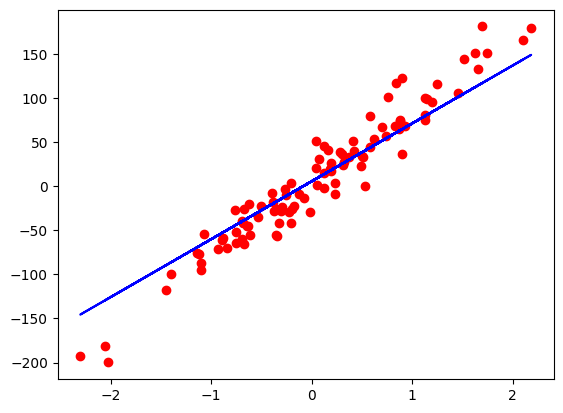

In [15]:
# plot
predicted = model(x).detach().numpy()
plt.plot(X_numpy, y_numpy, 'ro')
plt.plot(X_numpy, predicted, 'b')
plt.show()